In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

from sklearn.linear_model import LinearRegression, Ridge, Lasso

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [2]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [3]:
ticker = 'I:SPX'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-10-16", to="2024-11-08", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

170638it [00:02, 56899.09it/s]


In [4]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

times = pd.DataFrame(ticker_hist['Time'].unique())
times.columns = ['Time']
times['Time'] = times['Time'].sort_values().reset_index(drop = True)

ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}


print('analyzing')

dates = ticker_hist['Date'].unique()

for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

    ticker_hist_date = pd.merge(left = times, right = ticker_hist_date, on = "Time", how = "outer")
    ticker_hist_date = ticker_hist_date.sort_values(by = 'Time').reset_index(drop = True)
    ticker_hist_date = ticker_hist_date.ffill()
    logReturns = ticker_hist_date['logOpen'].diff()[1:]
    
    a = np.median(logReturns)
    b = np.sum(
            np.abs(logReturns - a)
    ) / (len(logReturns))
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


0it [00:00, ?it/s]/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_13417/3761098696.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ticker_hist_date = ticker_hist_date.ffill()
437it [00:02, 166.79it/s]


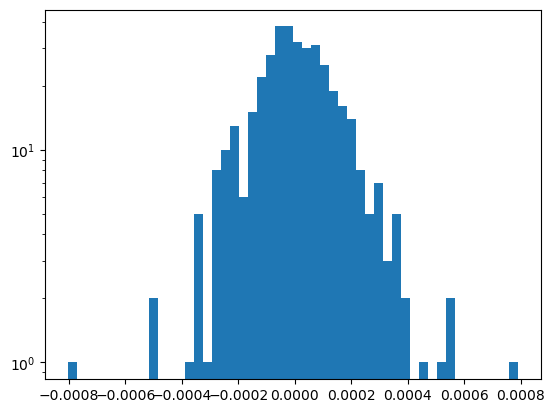

In [41]:
plt.hist(logReturns, bins = 50)
plt.yscale('log')

In [5]:
ab_params_df = pd.DataFrame(ab_params)
ab_params_df = ab_params_df.dropna()

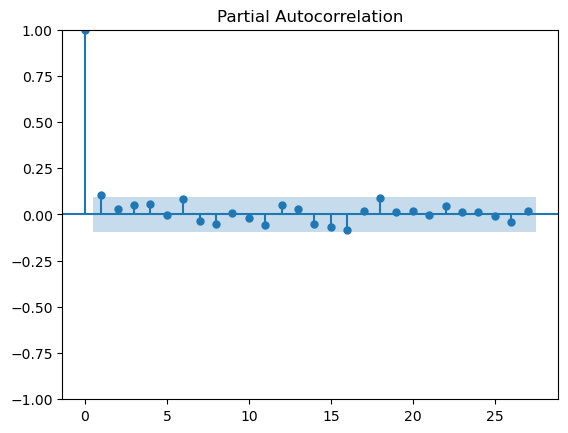

In [6]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

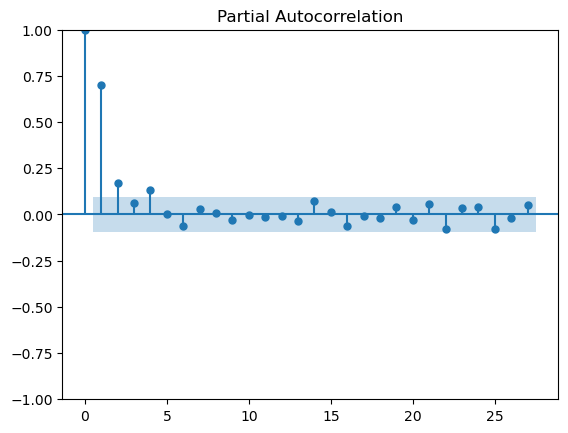

In [7]:
import statsmodels.tsa

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

In [8]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.1287391244605284), pvalue=np.float64(0.007176573654451988))

In [9]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.7019807747816645), pvalue=np.float64(8.159567229541215e-66))

In [10]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-2).iloc[:-2], ab_params_df['b'].iloc[:-2])

SignificanceResult(statistic=np.float64(0.5157490506883083), pvalue=np.float64(7.236210143578705e-31))

In [11]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

SignificanceResult(statistic=np.float64(-0.1413253805954976), pvalue=np.float64(0.003137525428700345))

In [12]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)



In [13]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1']))


0.5024797916960144
0.020657263571985163


In [14]:
ab_params_df['shifted_a_2'] = ab_params_df['a'].shift(-2)
ab_params_df['shifted_b_2'] = ab_params_df['b'].shift(-2)

In [15]:
r_b = LinearRegression()

r_b.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2'])
print(r_b.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2']))

r_a = LinearRegression()

r_a.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2'])
print(r_a.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2']))


0.5320154863661315
0.037120726952675875


In [16]:
r_b.coef_

array([ 0.10973847,  0.2518446 , -0.6555723 ,  0.49294078])

In [17]:
lr_b.coef_

array([-0.38973414,  0.67973041])

In [18]:
lr_a.coef_

array([0.1292632 , 0.02522653])

In [19]:
r_a.coef_

array([ 0.04453377, -0.04278687,  0.17256395,  0.06112008])

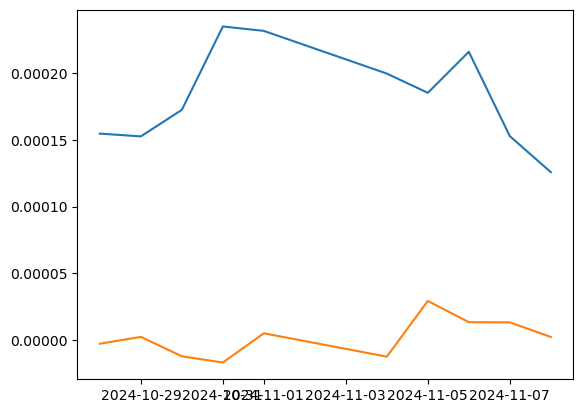

In [20]:
plt.plot(ab_params_df['b'][-10:])
plt.plot(ab_params_df['a'][-10:])

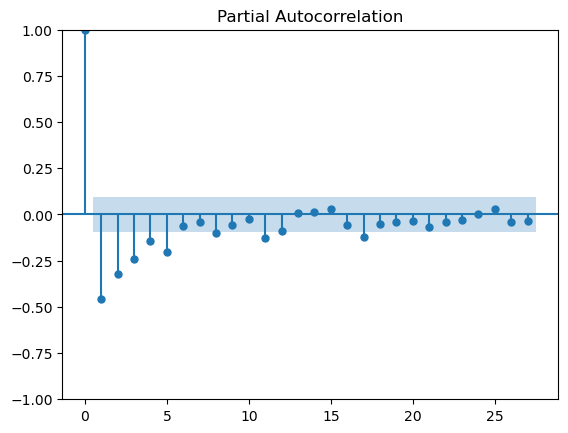

In [21]:
statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a'].diff()[1:]
)
plt.show()

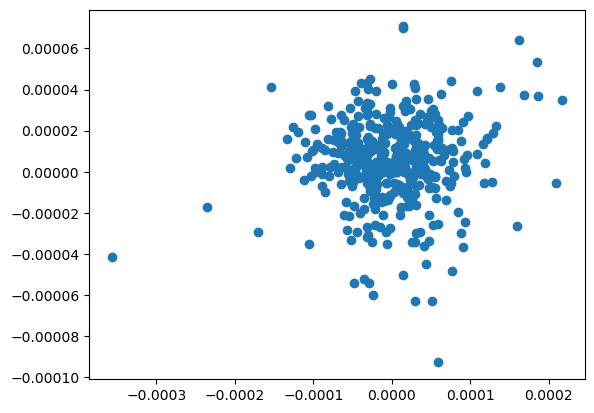

In [22]:
plt.scatter(ab_params_df['b'].diff(), ab_params_df['shifted_a_1'])

In [23]:
ab_params_df['b'].diff()

2023-02-15         NaN
2023-02-16    0.000055
2023-02-17   -0.000003
2023-02-21   -0.000054
2023-02-22    0.000062
                ...   
2024-11-04   -0.000032
2024-11-05   -0.000014
2024-11-06    0.000031
2024-11-07   -0.000063
2024-11-08   -0.000027
Name: b, Length: 436, dtype: float64

In [24]:
scipy.stats.pearsonr(ab_params_df['b'].diff()[1::-1], ab_params_df['a'].shift(-1)[1::-1])

PearsonRResult(statistic=np.float64(nan), pvalue=np.float64(1.0))

In [25]:
replicates = 100000

In [26]:
possible_final_returns = np.zeros(replicates)
for r in tqdm(range(replicates)):
    samples = np.random.laplace(
        loc=r_a.predict(ab_params_df[
            ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1], 
        scale=r_b.predict(
            ab_params_df[
                ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1],
        size=len(ticker_hist_date)
    )

    possible_final_returns[r] = samples.sum()


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [01:28<00:00, 1129.54it/s]


In [27]:
r_a.predict(ab_params_df[['a', 'b', 'shifted_a_1', 'shifted_b_1']].dropna())[-1]

np.float64(2.2162207569309866e-06)

In [28]:
r_b.predict(ab_params_df[['a', 'b', 'shifted_a_1', 'shifted_b_1']].dropna())[-1]

np.float64(0.00015654381963537995)

In [29]:
np.std(possible_final_returns)

np.float64(0.004370785783044017)

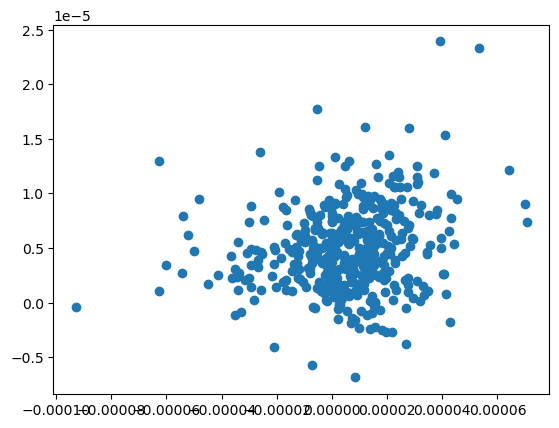

In [30]:
plt.scatter(
    ab_params_df.dropna()['shifted_a_2'], 
    r_a.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']]
    )
)

(332.0, 432.0)

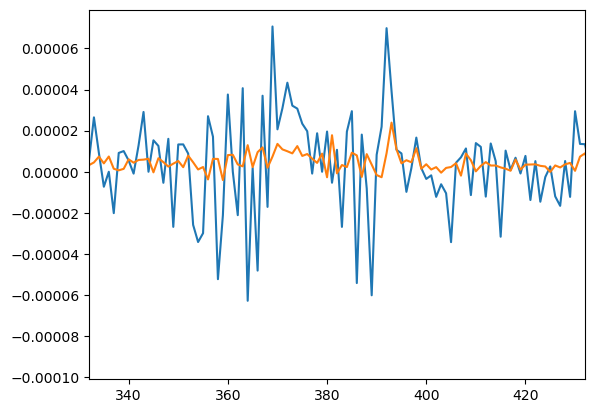

In [31]:
plt.plot(ab_params_df.dropna()['shifted_a_2'].reset_index(drop=True))
plt.plot(r_a.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']]))

plt.xlim(332,432)

# declare spot ticker price

In [33]:
spot_spx_price = 5995.

In [32]:
upper_call = 6035.
lower_call = 6030.
upper_put = 5960.
lower_put = 5955.

In [34]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_final_returns))

In [35]:
print(np.mean(possible_final_prices))
print(np.std(possible_final_prices))



6000.202162479811
26.22581754827594


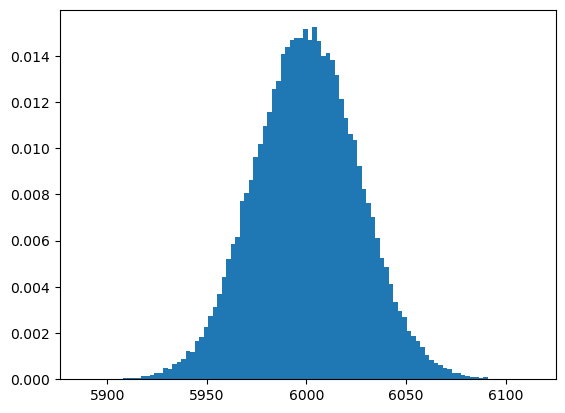

In [36]:
plt.hist(possible_final_prices, bins = 100, density = True)

plt.show()

In [37]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

In [38]:
len(ticker_hist_date)

391

In [39]:
6.5*60

390.0

Text(0.5, 1.0, 'avg payout is -0.8')

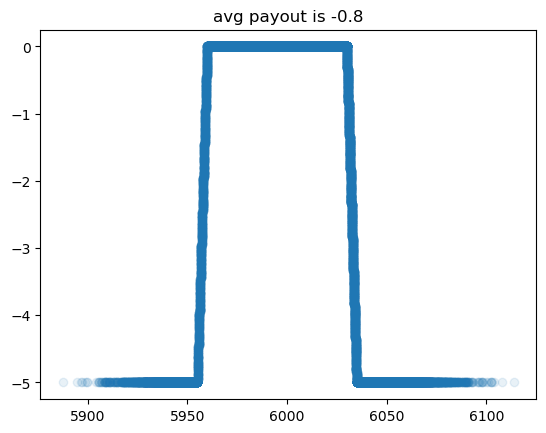

In [40]:
plt.scatter(possible_final_prices, payouts, alpha=0.1)
mean_payout = np.round(np.mean(payouts), 2)
plt.title(f'avg payout is {mean_payout}')

# compute cost of trade and max loss

In [113]:
cost_of_trade = 1.1
max_loss = 5

In [114]:
p = (max_loss - cost_of_trade)/max_loss

In [115]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is 2.220446049250313e-16


In [116]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.4729545454545455
